In [ ]:
# 0) Imports
# pip install numpy pandas matplotlib ipython pyreadr statsmodels scikit-learn scipy pygam ISLP

import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from IPython.display import display
import pyreadr


import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.datasets import get_rdataset

import sklearn.model_selection as skm
from sklearn.discriminant_analysis import (LinearDiscriminantAnalysis as LDA,
                                           QuadraticDiscriminantAnalysis as QDA)
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.model_selection import (cross_validate,
                                     KFold,
                                     ShuffleSplit,
                                     LeaveOneOut)
from sklearn.base import clone
from sklearn.metrics import roc_curve, auc, confusion_matrix,classification_report
from sklearn.metrics import accuracy_score, log_loss
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.tree import (DecisionTreeClassifier as DTC,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)
from sklearn.ensemble import (RandomForestRegressor as RFR,
                              GradientBoostingRegressor as GBR,
                              RandomForestClassifier as RFC,
                              GradientBoostingClassifier as GBC)
from sklearn.preprocessing   import StandardScaler, PolynomialFeatures
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import (LinearRegression,
                                  LogisticRegression,
                                  RidgeCV,
                                  LassoCV,
                                  ElasticNetCV,
                                  LogisticRegressionCV)

from ISLP import load_data, confusion_table
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)
from ISLP.models import sklearn_sm
from ISLP.models import (Stepwise,
                         sklearn_selected,
                         sklearn_selection_path)
from ISLP.models import bs, ns
from ISLP.models import contrast
from ISLP.transforms import (BSpline,
                             NaturalSpline)
from ISLP.pygam import (approx_lam,
                        degrees_of_freedom,
                        plot as plot_gam,
                        anova as anova_gam)

from pygam import (s as s_gam,
                   l as l_gam,
                   f as f_gam,
                   LinearGAM,
                   LogisticGAM)

from functools import partial

# Unsupervised Learning
from sklearn.cluster import (KMeans ,
                             AgglomerativeClustering )
from scipy.cluster.hierarchy import (dendrogram ,
                                     cut_tree)
from ISLP.cluster import compute_linkage

**Άσκηση 1:**

Τo αρχείο prob2.Rdata περιέχει τα dataframes p2train, p2test τα οποία είναι τα training και test sets, αντίστοιχα, από μετρήσεις μιας ανεξάρτητης μεταβλητής x και μιας εξαρτημένης μεταβλητής y. 

(α) Εφαρμόστε μοντέλα πολυωνυμικής παλινδρόμησης βαθμού 2,3,6,9 στο training set. Βρείτε το μοντέλο με το μικρότερο mean square error μέσω cross-validaton στο training set. 

(β) Για το μοντέλο που καταλήξατε στο (α), υπολογίστε το mean square predicton error από το test set. 

(γ) Εφαρμόστε το μοντέλο natural splines στο training set, με αριθμό κόμβων 2. 

(δ) Για το μοντέλο που καταλήξατε στο (γ), υπολογίστε το mean square predicton error από το test set.

In [68]:
#0) Load the data
df=pyreadr.read_r('prob2.Rdata')
p2train = df['p2train']
p2test = df['p2test']

#Prepare the variables
X_train = p2train.drop(columns=['y'])
y_train = p2train['y'] 

# a) Fit polynomial regression models with different degrees
deg=[2,3,6,9]
cv_error = np.zeros(4)
X=np.array(X_train)
M = sklearn_sm(sm.OLS)

for i, d in enumerate(deg):
    poly = PolynomialFeatures(degree=d, include_bias=True)
    X_new = poly.fit_transform(X)
    M_CV = cross_validate(M,
                          X_new,
                          y_train,
                          cv=KFold(n_splits=5, shuffle=True, random_state=42))
    cv_error[i] = np.mean(M_CV['test_score'])

print("The best score was with " + str(deg[np.argmin(cv_error)])+ " degree polynomial with cv " + str(np.min(cv_error)))

The best score was with 9 degree polynomial with cv 0.16100047450395363


In [76]:
#c) Fit polynomial regression model with the best degree
ms = MS([poly('x', degree=b_deg)])
X_train_poly = ms.fit_transform(X_train)
model = sm.OLS(y_train, X_train_poly).fit()

#d) Transform test data, predict, and compute MSE
X_test = p2test.drop(columns=['y'])
y_test = p2test['y']
X_test_poly = ms.transform(X_test)

y_pred = model.predict(X_test_poly)

test_mse = np.mean((y_test - y_pred) ** 2)
print(f"Test MSE (degree={b_deg}): {test_mse}")

Test MSE (degree=9): 0.1845480296874893


In [78]:
# c) Natural spline with 2 knots equiv with df=3

var=MS([ns('x', df=3)])
X_train_ns = var.fit_transform(X_train)
model_ns = sm.OLS(y_train, X_train_ns).fit()

# Transform test data, predict, and compute MSE
X_test_ns = var.transform(X_test)
y_pred_ns = model_ns.predict(X_test_ns)
test_mse_ns = np.mean((y_test - y_pred_ns) ** 2)
print(f"Test MSE (Natural Spline, df=3): {test_mse_ns}")

Test MSE (Natural Spline, df=3): 0.45529864798858255


**Άσκηση 2**

Τo αρχείο prob3.Rdata περιέχει τα dataframes p3train, p3test τα οποία είναι τα training και test sets, αντίστοιχα, από δεδομένα λοίμωξης παιδιών. Οι μεταβλητές fever_hours, age, sex, wcc, prevAB, pct, crp είναι οι πιθανοί παράγοντες ενώ η μεταβλητή Infecton δείχνει την ύπαρξη λοίμωξης (0=αρνητικό, 1=θετικό). 

(α) Δημιουργήστε ένα δέντρο απόφασης με βάση το training set για πρόβλεψη της λοίμωξης βασισμένο μόνο στις μεταβλητές wcc και pct. Σχεδιάστε το δέντρο στον υπολογιστή. Σχεδιάστε στην κόλλα σας τις περιοχές πρόβλεψης 0 ή 1 στο καρτεσιανό 
επίπεδο των wcc, pct, με βάση τα αποτελέσματα του δέντρου.

(β) Εφαρμόστε το δέντρο που βρήκατε στο (α) στο test set, και υπολογίστε τα ποσοστά λάθους ανά κατηγορία (ψευδώς θετικά και ψευδώς αρνητικά).

(γ) Δημιουργήστε ένα μοντέλο πρόβλεψης βασισμένο στον αλγόριθμο random forest και το training set, με όλες τις ανεξάρτητες μεταβλητές και τιμές της παραμέτρου m=2 και 3. Εφαρμόστε τα μοντέλα που βρήκατε στο test set και επιλέξτε αυτό που έχει το μικρότερο misclassificaton error. Για το μοντέλο αυτό υπολογίστε τα ποσοστά λάθους ανά κατηγορία (ψευδώς θετικά και ψευδώς αρνητικά). 


In [96]:
#0) Load the data
df2=pyreadr.read_r('prob3.Rdata')

p3train = df2['p3train']
p3test = df2['p3test']

X_train = p3train[['wcc', 'pct']]
X_test = p3test[['wcc', 'pct']]

y_train = p3train['Infection']
y_test = p3test['Infection']

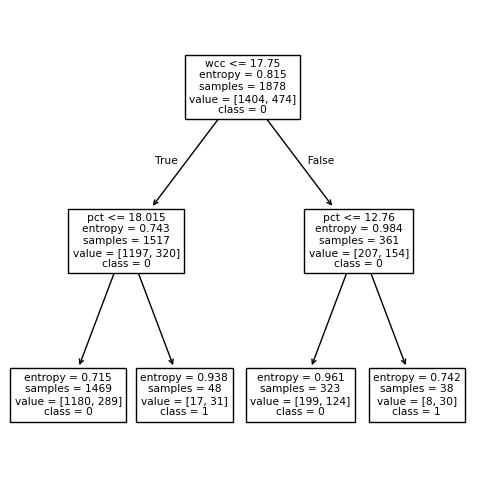

In [110]:
# a) Classification Tree
vars=MS(['wcc', 'pct'], intercept=False)
X=vars.fit_transform(X_train)
# feature_names = list(D.columns)
# X= np.asarray(D)

# Fit a decision tree classifier
clf = DTC(criterion='entropy',
           max_depth=2,
           random_state=0)

clf.fit(X, y_train)

# Plot the decision tree
ax = subplots(figsize=(6,6))[1]
plot_tree(clf,
          class_names=clf.classes_.astype(str),
          feature_names=feature_names,
          ax=ax);

In [114]:
#b) Predictions and confusion table
y_pred = clf.predict(X_test)
display(confusion_table(y_test, y_pred))

Truth,0,1
Predicted,,
0,341,7
1,115,7


In [116]:
# c) Classification with Random Forests
clf2 = RFC(n_estimators=100,
           max_depth=2,
           random_state=0)
clf2.fit(X, y_train)
# Predictions and confusion table
y_pred2 = clf2.predict(X_test)
display(confusion_table(y_test, y_pred2))

clf3 = RFC(n_estimators=1000,
           max_depth=3,
           random_state=0)
clf3.fit(X, y_train)
# Predictions and confusion table
y_pred3 = clf3.predict(X_test)
display(confusion_table(y_test, y_pred3))

Truth,0,1
Predicted,,
0,345,3
1,118,4


Truth,0,1
Predicted,,
0,343,5
1,116,6


**Άσκηση 3**

Boosting for Regression Tree 

In [121]:
df3=pyreadr.read_r('prob4.Rdata')

p4train = df3['p4train']
p4test = df3['p4test']

X_train = p4train.drop(columns=['brozek'])
y_train = p4train['brozek']
X_test = p4test.drop(columns=['brozek'])
y_test = p4test['brozek']

In [127]:
# fit a boosting model
variables = MS(X_train.columns.tolist(), intercept=False)
X_train = variables.fit_transform(X_train)

X_test = variables.transform(X_test)

gbm = GBR(n_estimators=1000,
           learning_rate=0.1,
           max_depth=3,
           random_state=42)

gbm.fit(X_train, y_train)

# Predictions and confusion table
y_pred_gbm = gbm.predict(X_test)
test_mse_gbm = np.mean((y_test - y_pred_gbm) ** 2)
print(f"Test MSE (Gradient Boosting): {test_mse_gbm}")

Test MSE (Gradient Boosting): 18.314592781070893


**Άσκηση 5**

Lasso + Ridge Cross Validation

In [135]:
import numpy as np
from sklearn.linear_model    import RidgeCV, LassoCV
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import make_pipeline
from sklearn.metrics         import mean_squared_error, r2_score

# 1) α grid
alphas = np.logspace(-3, 3, 50)

# 2) RidgeCV without store_cv_values
ridge_cv = RidgeCV(
    alphas=alphas,
    cv=5,               # 5‑fold CV
    scoring='neg_mean_squared_error'
)

ridge_pipe = make_pipeline(
    StandardScaler(),
    ridge_cv
)

ridge_pipe.fit(X_train, y_train)
print(f"Ridge best α: {ridge_cv.alpha_:.4f}")

y_pred_ridge = ridge_pipe.predict(X_test)
print("Ridge MSE:", mean_squared_error(y_test, y_pred_ridge))
print("Ridge R²: ", r2_score(y_test, y_pred_ridge))


# 3) LassoCV (unchanged)
lasso_cv = LassoCV(
    alphas=alphas,
    cv=5,
    max_iter=5000,
    n_jobs=-1,
    random_state=42
)

lasso_pipe = make_pipeline(
    StandardScaler(),
    lasso_cv
)

lasso_pipe.fit(X_train, y_train)
print(f"Lasso best α: {lasso_cv.alpha_:.4f}")

y_pred_lasso = lasso_pipe.predict(X_test)
print("Lasso MSE:", mean_squared_error(y_test, y_pred_lasso))
print("Lasso R²: ",  r2_score(y_test, y_pred_lasso))


Ridge best α: 1.5264
Ridge MSE: 20.907147461787343
Ridge R²:  0.6676616564367512
Lasso best α: 0.1600
Lasso MSE: 22.000839513713093
Lasso R²:  0.6502764150703892
